# **MODELOS FOCADOS EM EMBEDDINGS**

## **CRIANDO WORD EMBEDDINGS SEM UM MODELO DE LINGUAGEM**

No material passado, os *word embeddings* eram subprodutos do treinamento de um modelo de linguagem. Para criar bons *embeddings* não é bom nos restringirmos a olhar apenas para a sequência de palavaras anteirores, relações importantes podem ser identificadas levando em conta as palavras futuras também (as variações do *word2vec* fazem isso.)

Além de usar as palavras futuras para treinar os *word embeddings*, as variações do modelo citado acima também visam diminuir a complexidade computacional necessária para esse treinamento. A principal justificativa para isso é que permite o treinamento em um dataset de entrada maior, o que por si só deve resultar em melhores *embeddings*.

Duas técnicas que foram importante para a evolução do *word2vec*, mas que não são mais usadas na versão dominante do algoritmo *word2vec* são:
* **Softmax hierárquica;**
* **Modelo continuous-bag-of-words (CBOW).**

### **COMPLEXIDADE COMPUTACIONAL**

Um obstáculo fundamental na produção de *word embeddings* a partir de modelos de linguagem neurais era a complexidade computacional de treinar um modelo de linguagem com um grande *corpus* de texto. Realizando a análise sobre o tempo gasto por um modelo de linguagem neural, notaram que, baseado em um modelo típico, a camada que calcula os *embeddings* tem baixa complexidade, a(s) camada(s) oculta(s) ou recorrente(s) e a camada softmax final tem alta complexidade. 

No entanto, como trabalhos anteriores sobre redução da complexidade computacional de modelos de linguagem neurais mostraram que uma técnica conhecida como softmax hierárquica poderia ser usada para reduzir a complexidade da camada softmax, o artigo inicial do *word2vec* não se concentrou nessa camada, simplesmente assumiu que a softmax hierárquica era usada.

A outra otimização é remover a(s) camada(s) oculta(s). Isso é possível pois os *embeddings* são codificados na primeira camada, a camada de *embedding*, e já que o objetivo não é criar um modelo de linguagem poderoso. Após essas duas mudanças, chegamos a um modelo no qual a primeira camada converte as entradas em *word embeddings* (ou seja, é uma camada de *embedding*) simplesmente seguida por uma camada softmax (na realidade, uma softmax hierárquica) como a camada de saída. A única não linearidade no modelo é a própria camada softmax. Essas duas modificações devem resolver a maior parte da complexidade computacional no modelo de linguagem e, assim, permitir um dataset de treinamento maior.

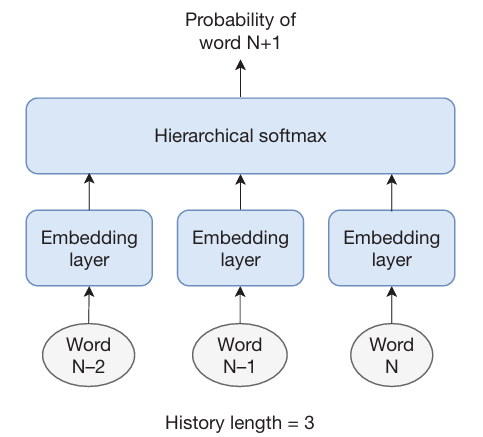 *Modelo simples para criação de embeddings.*

*Isso ainda não representa o que é usado no word2vec, pois ele considera apenas palavras anteriores e não as futuras também.*

### **CONTINUOUS BAG-OF-WORDS**

Para o nosso modelo levar em conta as palavras futuras é simples. Basta selecionarmos uma palavra a ser prevista e usar as *K* palavras precedentes e as *K* palavras subsequentes como entrada para a rede. A partir disso, a entrada para a camada softmax, no *word2vec* é a média dos *embeddings* para as 2x*K* palavras que usamos como entrada e, assim, produzir um único vetor de *embedding* de tamanho *M*.

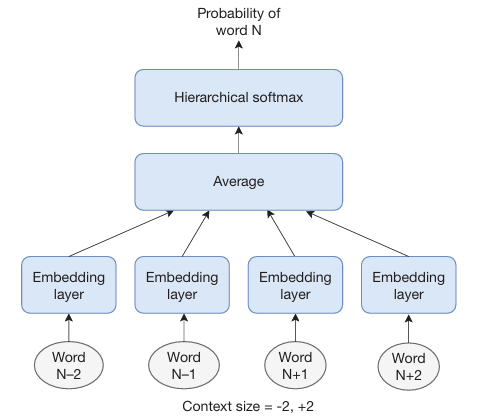 *Representação do CBOW com K=2*

Tirar a média dos vetores tem o efeito de que a ordem em que são apresentados à rede não importa, assim como a ordem não importa para um modelo *bag-of-words*. O nome *continuous* no modelo indica que ele se baseia em vetores de palavras de valor real. No entanto, vale notar que o *CBOW* não se baseia no documento inteiro, mas apenas nas 2×K palavras ao redor.

O modelo *CBOW* demonstrou superar os *embeddings* criados a partir de um modelo de linguagem baseado em *RNN* em termos de quão bem ele captura estruturas semânticas no *dataset*, além de acelerar significativamente o tempo de treinamento.

### **CONTINUOUS SKIP-GRAM**

Esse modelo é diferente do que vimos anteriormente. Em vez de prever uma única palavra com base nas palavras vizinhas (conhecidas como **contexto**), ele tenta prever as palavras vizinhas com base em uma única palavra. Isso pode parecer estranho à primeira vista, mas resulta em um modelo mais simples. Ele recebe uma única palavra como entrada e cria um *embedding*. Esse *embedding* é então alimentado a uma camada softmax *fully connected*, que produz probabilidades para cada palavra no vocabulário, mas agora o treinamos para produzir probabilidades não nulas para múltiplas palavras (as palavras que cercam a palavra de entrada), em vez de apenas produzir uma probabilidade não nula para uma única palavra no vocabulário.

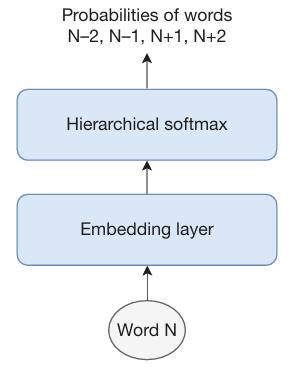 *Exemplo desse modelo.*

Uma pergunta válida é por que isso funcionaria bem. Notamos que palavras que têm propriedades em comum (por exemplo, são sinônimos ou similares de alguma outra forma) muitas vezes se cercam de um conjunto semelhante de palavras, como em nossas frases *“that is exactly what I mean”* e *“that is precisely what I mean”*. Se treinarmos em ambas as frases, nosso modelo *continuous skip-gram* tem a tarefa de produzir uma probabilidade não nula para as palavras *that*, *is*, *what*, *I*, e *mean* tanto quando apresentado com *exactly* quanto com *precisely* em sua entrada. Uma maneira simples de conseguir isso é produzir *embeddings* nos quais essas duas palavras estejam próximas uma da outra no espaço vetorial. Esta explicação envolve uma boa dose de argumentação superficial, mas lembre-se que o modelo evoluiu com base em **estudos empíricos**.

### **REDUZINDO COMPLEXIDADE COMPUTACIONAL**

O modelo *continuous skip-gram* original usava a softmax hierárquica em sua saída, mas em um artigo subsequente, o algoritmo foi modificado para torná-lo ainda mais rápido e simples. A observação geral foi que tanto a softmax quanto a softmax hierárquica visam calcular as probabilidades corretas para todas as palavras no vocabulário, o que é importante para um modelo de linguagem, mas, como mencionado anteriormente, o objetivo do *word2vec* é criar bons *word embeddings*, em oposição a um bom modelo de linguagem. Com esse histórico, o algoritmo foi modificado substituindo a camada softmax por um novo mecanismo chamado **amostragem negativa (negative sampling)**. A observação foi que, em vez de calcular uma distribuição de probabilidade verdadeira em todas as palavras do vocabulário, deveria ser possível produzir bons *embeddings* se ensinarmos a rede a apenas identificar corretamente as palavras vizinhas, que estão na ordem de dezenas de palavras, em vez de dezenas de milhares. Além disso, é necessário garantir que a rede não produza incorretamente altas probabilidades para palavras que não fazem parte do conjunto de palavras vizinhas.

Podemos alcançar isso da seguinte maneira. Para cada palavra *K* no vocabulário, mantemos um único neurônio de saída *NK* correspondente, com uma função de ativação sigmoide. Para cada exemplo de treinamento *X*, agora treinamos em série cada um dos neurônios *NX−2*, *NX−1*, *NX+1*, *NX+2* correspondentes às palavras vizinhas (este exemplo assume que consideramos quatro palavras vizinhas). Ou seja, convertemos o problema softmax em uma série de problemas de classificação. Isso não é suficiente, no entanto. Uma solução ingênua para este problema de classificação é que todos os neurônios de saída sempre produzam 1, porque eles são apenas amostrados (treinados) para os casos em que suas palavras correspondentes estão ao redor da palavra de entrada. Para contornar este problema, precisamos introduzir também algumas amostras negativas, ou seja, para cada lavara de entrada, faça o seguinte:
1. Identifique os neurônios de saída correspondentes a cada palavra vizinha;
2. Treine esses neurônios para produzir a saída 1 quando a rede for apresentada à palavra de entrada;
3. Identifique os neurônios de saída correspondentes a um número de palavras aleatórias que não são vizinhas da palavra de entrada;
4. Treine esses neurônios para produzir a saída 0 quando a rede for apresentada à palavra de entrada.

Por exemplo, imagine que o seu vocabulário tem 50.000 palavras. Com isso que foi explicado acima, em vez de perguntar "Qual é a palavra de contexto correta entre todas as 50.000 opções?", o modelo faz uma série de perguntas muito mais simples:

1. Pergunta para a palavra correta: A palavra "gato" é uma palavra de contexto para "sentou"? (A resposta esperada é Sim/1)
2. Pergunta para uma palavra aleatória: A palavra "banana" é uma palavra de contexto para "sentou"? (A resposta esperada é Não/0)
3. Pergunta para outra palavra aleatória: A palavra "carro" é uma palavra de contexto para "sentou"? (A resposta esperada é Não/0)

## **HANDS-ON: EXEMPLO DE PROGRAMAÇÃO**

Cerca de um ano após a publicação do *word2vec*, o *GloVe* foi publicado. O *GloVe* é um algoritmo matematicamente projetado para criar *word embeddings* bem-comportados. Em particular, o objetivo é que os *embeddings* capturem relações sintáticas e semânticas entre as palavras. Os *embeddings* estão disponíveis para download e estão contidos em um arquivo de texto no qual cada linha representa um *word embedding*. O primeiro elemento é a própria palavra, seguida pelos elementos do vetor separados por espaços em branco.

### Carregando os embeddings do modelo GloVe

In [4]:
import numpy as np 
import scipy.spatial 

#Lendo o arquivo e os embeddings
def read_embeddings():
    FILE_NAME = ...
    embeddings = {}
    file = open(FILE_NAME, 'r', encoding='utf-8')
    for line in file:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings[word] = vector
    file.close()
    print('Read %s embeddings.' % len(embeddings))
    return embeddings

### Função para identificar e printar as três palavras mais próximas no espaço vetorial

In [ ]:
def print_n_closest(embeddings, vec0, n):
    word_distances = {}
    for (word, vec1) in embeddings.items():
        distance = scipy.spatial.distance.cosine(vec1, vec0)
        word_distances[distance] = word
    #Printando as palavras ordenadas por distância
    for distance in sorted(word_distances.keys())[:n]:
        word = word_distances[distance]
        print(word + ': %6.3f' % distance)

### Printando as três palavras mais próximas de 3 exemplos

In [ ]:
embeddings = read_embeddings()

lookup_word = 'hello'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings, embeddings[lookup_word], 3)

lookup_word = 'precisely'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings, embeddings[lookup_word], 3)

lookup_word = 'dog'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings, embeddings[lookup_word], 3)

### Exemplo de aritmética vetorial com os *embeddings*

In [ ]:
lookup_word = 'king'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings, embeddings[lookup_word], 3)

lookup_word = '(king - man + woman)'
print('\nWords closest to ' + lookup_word)
vec = embeddings['king'] - embeddings['man'] + embeddings['woman']
print_n_closest(embeddings, vec, 3)

Podemos ver que a palavra mais próxima de king (ignorando o próprio king) é prince, seguida por queen. Também vemos que a palavra mais próxima de (king - man + woman) ainda é king, mas a segunda mais próxima é queen; ou seja, os cálculos resultaram em um vetor que está mais do lado feminino, já que queen agora está mais próxima do que prince.

### Aritimética vetorial com países e capitais

In [ ]:
lookup_word = 'sweden'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings, embeddings[lookup_word], 3)

lookup_word = 'madrid'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings, embeddings[lookup_word], 3)

lookup_word = '(madrid - spain + sweden)'
print('\nWords closest to ' + lookup_word)
vec = embeddings['madrid'] - embeddings['spain'] + embeddings['sweden']
print_n_closest(embeddings, vec, 3)

Como você pode ver na saída a seguir, as palavras mais próximas de Sweden são os países vizinhos Denmark e Norway. Da mesma forma, as palavras mais próximas de Madrid são Barcelona e Valencia, duas outras cidades espanholas importantes. Agora, remover Spain de Madrid (sua capital) e, em vez disso, adicionar Sweden resulta na capital sueca de Stockholm, que aparentemente surgiu do nada, em oposição ao exemplo rei/rainha, onde queen já estava intimamente relacionada a king.